# Module 2a · From Papers to a Dataset: Schema, Evaluation, and Prompt Optimization

The task: turn a pile of papers into a clean table, one row per device, with the analyte, detection limits, materials, and test conditions. We make an LLM do it, with a schema and a measured evaluation so the output can be trusted and improved.

A chat agent reads one paper at a time. What you actually want is a repeatable pipeline that produces a validated dataset over the whole corpus, with an accuracy number you can push up. That pipeline is the point of this module.

Starting from a plain first-draft prompt, we raise field accuracy on a held-out test set from about 0.68 to 0.83 by adding three things one at a time: metric-driven prompt optimization, few-shot examples, and a second optimization pass. The evaluation is what makes each addition a decision rather than a guess.

The data is 150 papers from the T3 FET-biosensor corpus (R. Ding et al.), with hand-curated ground truth. Cached model outputs ship with the notebook, so everything reproduces with no API key.

## 0. Setup

In [ ]:
# Colab setup: fetch the data and enter this module's folder. No-op when run locally.
import os, sys
REPO = "https://github.com/ruiding-uchicago/NRT_Training_Materials.git"
MODULE = "module_2a_text_to_data"
if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != MODULE:
    root = "/content/NRT_Training_Materials"
    if not os.path.isdir(root):
        os.system("git clone --depth 1 " + REPO + " " + root)
    os.chdir(root + "/" + MODULE)
print("ready in", os.getcwd())

In [1]:
import sys, subprocess, os
if "google.colab" in sys.modules:
    subprocess.run([sys.executable,"-m","pip","install","-q","requests","pydantic","pandas","matplotlib"])
import os, json, glob, re, math, requests
import pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]=110; os.makedirs("figures",exist_ok=True)

USE_CACHE = True                       # True: read shipped outputs (no key, no cost). False: call the API live.
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY","")
WORKER = "deepseek/deepseek-v4-flash"      # cheap worker, does the extraction
OPTIMIZER = "deepseek/deepseek-v4-pro"     # strong model, rewrites the prompt

## 1. The data

Each paper is plain text. Ground truth is one record of 8 fields per paper. We split into train / validation / test: train drives prompt edits, validation chooses which edits to keep, and test is touched only to report final numbers.

In [2]:
PAPERS=sorted(glob.glob("data/papers/*.txt")); STEMS=[os.path.basename(p)[:-4] for p in PAPERS]
gold=json.load(open("data/gold_core.json")); split=json.load(open("data/split3.json"))
train,val,test=split["train"],split["val"],split["test"]
CORE=["sensor_type","detect_target","lower_detection_limit","upper_detection_limit",
      "probe_material","test_operating_temperature (celcius)","pH_value","test_medium"]
print(len(PAPERS),"papers | train",len(train),"val",len(val),"test",len(test))
ex = ("10.1002_adfm.201001560" if "10.1002_adfm.201001560" in gold
      else next(s for s in test if gold[s][0]["sensor_type"]=="gas"))
print("\nexcerpt:",open(f"data/papers/{ex}.txt").read()[:300].strip(),"...")
print("\ngold:",json.dumps(gold[ex][0],ensure_ascii=False))

150 papers | train 60 val 39 test 51

excerpt: Gate-Bias Controlled Charge Trapping as a Mechanism for NO2 Detection with Field-Effect Transistors
Anne-Marije Andringa, Juliaan R. Meijboom, Edsger C. P. Smits, Simon G. J. Mathijssen, Paul W. M. Blom, Dago M. de Leeuw
First published: 15 November 2010 https://doi.org/10.1002/adfm.201001560Citatio ...

gold: {"sensor_type": "gas", "detect_target": "nitrogen dioxide", "lower_detection_limit": "10 ppb", "upper_detection_limit": "3 ppm", "probe_material": "zinc oxide", "test_operating_temperature (celcius)": "40 °C", "pH_value": "-1", "test_medium": "nitrogen"}


## 2. The schema: a contract for a clean dataset

Pydantic makes the output a dataset rather than free text: every record must have these fields, and the validator coerces and checks them. We add `source_quote` so a record can carry the sentence it came from.

In [3]:
from pydantic import BaseModel, Field, ConfigDict, field_validator
from typing import List
class Record(BaseModel):
    model_config=ConfigDict(populate_by_name=True, extra="ignore")
    sensor_type: str = Field("", description="gas, liquid, or bio")
    detect_target: str = ""
    lower_detection_limit: str = ""
    upper_detection_limit: str = ""
    probe_material: str = ""
    temperature_c: str = Field("", alias="test_operating_temperature (celcius)")
    pH_value: str = ""
    test_medium: str = ""
    source_quote: str = ""
    @field_validator("*", mode="before")
    @classmethod
    def _s(cls,v): return "" if v is None else str(v)   # model outputs may contain ints (pH -1)
class Extraction(BaseModel):
    records: List[Record]
print(Extraction(records=[{"sensor_type":"gas","pH_value":-1}]).records[0])

sensor_type='gas' detect_target='' lower_detection_limit='' upper_detection_limit='' probe_material='' temperature_c='' pH_value='-1' test_medium='' source_quote=''


## 3. Extract one paper

The worker is `deepseek-v4-flash` via OpenRouter in JSON mode. The function is cache-backed: it returns the shipped result unless you set `USE_CACHE=False` and a key.

In [4]:
def chat(messages, model=WORKER, reasoning=True, json_mode=True):
    body={"model":model,"messages":messages,"reasoning":{"enabled":reasoning}}
    if json_mode: body["response_format"]={"type":"json_object"}
    r=requests.post("https://openrouter.ai/api/v1/chat/completions",
        headers={"Authorization":f"Bearer {OPENROUTER_API_KEY}","Content-Type":"application/json"},
        data=json.dumps(body),timeout=300); r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]
def stringify(r): return {k:("" if v is None else str(v)) for k,v in r.items()}
def extract_paper(stem, prompt, version):
    cache=f"data/cache/{version}/{stem}.json"
    if USE_CACHE and os.path.exists(cache):
        recs=json.load(open(cache)).get("records",[])
    else:
        obj=json.loads(chat([{"role":"user","content":open(f'data/papers/{stem}.txt').read()+"\n\n"+prompt}]))
        recs=obj.get("records",obj if isinstance(obj,list) else [obj])
        os.makedirs(os.path.dirname(cache),exist_ok=True); json.dump({"stem":stem,"records":recs},open(cache,"w"),ensure_ascii=False,indent=2)
    return [stringify(r) for r in recs]
baseline_prompt=open("reference/human_init_prompt.md").read()
pred=Extraction(records=extract_paper(ex,baseline_prompt,"baseline")).records[0]
ks=["sensor_type","detect_target","lower_detection_limit","upper_detection_limit","probe_material","temperature_c","pH_value","test_medium"]
pd.DataFrame({"predicted":[getattr(pred,k) for k in ks],"gold":[gold[ex][0][f] for f in CORE]},index=CORE)

,predicted,gold
sensor_type,gas,gas
detect_target,nitrogen dioxide,nitrogen dioxide
lower_detection_limit,10 ppb,10 ppb
upper_detection_limit,1200 ppb,3 ppm
probe_material,zinc oxide,zinc oxide
test_operating_temperature (celcius),40 °C,40 °C
pH_value,-1,-1
test_medium,air (N2 carrier gas with NO2),nitrogen


The model is usually correct but phrases things differently, which is what makes scoring extraction hard. `NO2` vs `nitrogen dioxide` is the same chemical; `0.01 ppm` vs `10 ppb` is the same value. So the metric needs three kinds of comparison: exact for categories, unit-normalized for numbers, and a synonym-tolerant judge for chemicals.

## 4. The evaluation

Three field comparisons:
- **categorical** (`sensor_type`): exact match.
- **concentration / numeric** (detection limits, temperature, pH): parse the number, normalize units (10 ppb = 0.01 ppm), accept within a tolerance.
- **chemical** (`detect_target`, `probe_material`, `test_medium`): an LLM judge that treats synonyms, formulas, and abbreviations as equal and ignores morphology and support (a `ZnO nanowire` is `zinc oxide`). The judge verdicts are cached.

In [5]:
SUP=str.maketrans("⁰¹²³⁴⁵⁶⁷⁸⁹⁻⁺","0123456789-+")
UNITS=[("ppm",("ppm",1)),("ppb",("ppm",1e-3)),("ppt",("ppm",1e-6)),("mm",("M",1e-3)),("µm",("M",1e-6)),
       ("μm",("M",1e-6)),("um",("M",1e-6)),("nm",("M",1e-9)),("pm",("M",1e-12)),("fm",("M",1e-15)),("m",("M",1))]
UD=dict(UNITS)
def parse_conc(x):
    s=str(x).strip().lower().replace("−","-").replace("×","x").translate(SUP); u=p=None
    for un,_ in UNITS:
        mm=re.search(r'(?<![a-z])'+re.escape(un)+r'(?![a-z])',s)
        if mm: u=un;p=mm.start();break
    if u is None: return None
    n=s[:p].replace(" ",""); v=None
    m=re.search(r'(-?\d*\.?\d+)?[x*]10\^?(-?\d+)',n) or re.search(r'(-?\d*\.?\d+)?10\^(-?\d+)',n)
    if m: c=m.group(1); v=(float(c) if c not in(None,"","-","+",".") else 1.0)*10**int(m.group(2))
    if v is None:
        m=re.search(r'(-?\d*\.?\d+)e(-?\d+)',n); v=float(m.group(1))*10**int(m.group(2)) if m else None
    if v is None:
        m=re.search(r'-?\d*\.?\d+',n); v=float(m.group()) if m else None
    return (UD[u][0],v*UD[u][1]) if v is not None else None
def conc_match(a,b):
    a,b=str(a).strip(),str(b).strip()
    if a==""and b=="": return True
    if a==""or b=="": return False
    pa,pb=parse_conc(a),parse_conc(b)
    if pa and pb and pa[0]==pb[0] and pa[1]>0 and pb[1]>0: return abs(math.log10(pa[1]/pb[1]))<=0.5
    return a.lower().replace(" ","")==b.lower().replace(" ","")
def num_close(a,b,t):
    try: return abs(float(re.search(r'[-+]?\d*\.?\d+',str(a)).group())-float(re.search(r'[-+]?\d*\.?\d+',str(b)).group()))<=t
    except: return str(a).strip().lower()==str(b).strip().lower()
def norm(s): return re.sub(r'[\s\-_()]','',str(s).strip().lower())
judge=json.load(open("data/cache/judge2.json")) if os.path.exists("data/cache/judge2.json") else {}
def chem_match(p,g):   # ground truth g, prediction p
    p,g=str(p).strip(),str(g).strip()
    if p==""and g=="": return True
    if p==""or g=="": return False
    if norm(p)==norm(g): return True
    k="J2||"+g.lower()+"||"+p.lower()
    if k in judge: return judge[k]
    return False   # offline fallback (all evaluated pairs are cached)
CHEM={"detect_target","probe_material","test_medium"}; CONC={"lower_detection_limit","upper_detection_limit"}
def field_match(f,p,g):
    if f in CHEM: return chem_match(p,g)
    if f in CONC: return conc_match(p,g)
    if f=="test_operating_temperature (celcius)": return num_close(p,g,5)
    if f=="pH_value": return num_close(p,g,0.5)
    return norm(p)==norm(g)
def preds(version):
    return {os.path.basename(f)[:-5]:[stringify(r) for r in (json.load(open(f)).get("records",[]) or [])]
            for f in glob.glob(f"data/cache/{version}/*.json")}
def score(version, stems=test):
    P=preds(version); per={f:[0,0] for f in CORE}
    for s in stems:
        g=gold[s][0]; pr=P.get(s,[]); p=pr[0] if pr else {}
        for f in CORE: per[f][1]+=1; per[f][0]+=field_match(f,p.get(f,""),g.get(f,""))
    out=pd.Series({f:per[f][0]/per[f][1] for f in CORE}); out["MACRO"]=out[CORE].mean(); return out
score("baseline").round(3)

sensor_type                             0.824
detect_target                           0.843
lower_detection_limit                   0.549
upper_detection_limit                   0.608
probe_material                          0.882
test_operating_temperature (celcius)    0.333
pH_value                                0.706
test_medium                             0.706
MACRO                                   0.681
dtype: float64

## 5. Improving the prompt, step by step

We start from a plain prompt and add one improvement at a time, checking each on the held-out test set. At each step the exact prompt is printed in a banner, so you can see precisely what changed.

**Step 1: metric-driven prompt optimization.** Read the validation failures, and have the strong model (`deepseek-v4-pro`) rewrite the prompt. Run it for several rounds, keep a rewrite only when validation accuracy improves, and select on validation (never on test). This is the loop DSPy and TextGrad automate. The resulting prompt is `reference/auto_iter_prompt.md`.

The starting point is the project's real first-draft prompt:

In [6]:
print("="*64); print("PROMPT  ·  baseline (first-draft)"); print("="*64)
print(open("reference/human_init_prompt.md").read())

PROMPT  ·  baseline (first-draft)
After reading the scientific publication full text provided above, please try to generate formatted JSON file for extraction of important information. Leave "" for not available fields.

For instance:
{
"records": [
    {
      "sensor_type": "(gas/bio/liquid; please choose one)",
      "detect_target": "(target chemical name)",
      "lower_detection_limit": "xx ppm (or corresponding units)",
      "upper_detection_limit": "xx ppm (or corresponding units)",
      "probe_material": "(probe chemical name)",
      "test_operating_temperature (celcius)": "xx °C",
      "pH_value": "(use -1 for gas, otherwise a number, if pH sensor, use range like xx-yy)",
      "test_medium": "(the name of the medium, e.g. air, water, or other medium)"
    }
   (continue if the publication has recorded multiple different target been detected)
  ]
}


In [7]:
print("baseline             ", round(score("baseline")["MACRO"],3))
print("+ prompt optimization", round(score("auto_iter")["MACRO"],3))

baseline              0.681
+ prompt optimization 0.74


The optimizer rewrote it into the instructions below. Notice the concrete rules it found from the validation failures: default temperature to room temperature, use concentration rather than pH for liquid sensors, and fill both detection limits.

In [8]:
print("="*64); print("PROMPT  ·  after optimization (rewritten instructions)"); print("="*64)
print(open("reference/auto_iter_prompt.md").read())

PROMPT  ·  after optimization (rewritten instructions)
You are an expert at extracting structured sensor data from scientific papers. Read the full text and output a JSON object with key "records" containing an array. Each record must have all fields exactly as specified; never omit a field or output an empty string when a value can be determined. Infer and extract everything the paper supports.

{
  "records": [
    {
      "sensor_type": "gas/bio/liquid",
      "detect_target": "target chemical name",
      "lower_detection_limit": "value with unit",
      "upper_detection_limit": "value with unit",
      "probe_material": "sensing material name",
      "test_operating_temperature (celcius)": "value °C",
      "pH_value": "pH value or −1",
      "test_medium": "base medium name"
    }
  ]
}

Rules (follow exactly; use paper content, never guess beyond what is supported):

1. sensor_type
   - "gas": sensor detects gaseous analyte (including humidity, volatile organic vapours) in a gas

**Step 2: few-shot examples.** Add a handful of correct records from the train set to the prompt. Examples convey granularity that is hard to state in words, especially for `probe_material` (the concise key sensing species) and `test_medium` (the base medium only).

In [9]:
# the examples appended to the prompt (paper excerpts trimmed here for display)
_sp = open("reference/showcase_prompt.md").read()
_fs = _sp[_sp.index("Study these correctly"):] if "Study these correctly" in _sp else _sp
_fs = re.sub(r"(PAPER \(excerpt\):\n.{0,200}).*?\n\.\.\.", r"\1 [... excerpt trimmed ...]\n...", _fs, flags=re.S)
print("="*64); print("PROMPT  ·  few-shot examples appended (excerpts trimmed for display)"); print("="*64)
print(_fs)

PROMPT  ·  few-shot examples appended (excerpts trimmed for display)
Study these correctly extracted records and match their granularity and naming (probe_material = concise key sensing species; test_medium = base medium only):
{"sensor_type": "gas", "detect_target": "nitrogen dioxide", "lower_detection_limit": "10 ppb", "upper_detection_limit": "3 ppm", "probe_material": "zinc oxide", "test_operating_temperature (celcius)": "40 °C", "pH_value": "-1", "test_medium": "nitrogen"}
{"sensor_type": "gas", "detect_target": "ammonia", "lower_detection_limit": "4 ppm", "upper_detection_limit": "60 ppm", "probe_material": "6PTTP6(5,5′-Bis(4-hexylphenyl)-2,2′-bithiophene)/8-3-NTCDI(N,N′-Bis(3-(perfluoroctyl)propyl)-1,4,5,8-naphthalenetetracarboxylic diimide)", "test_operating_temperature (celcius)": "25 °C", "pH_value": "−1", "test_medium": "air"}
{"sensor_type": "gas", "detect_target": "diethyl chlorophosphate", "lower_detection_limit": "10 ppb", "upper_detection_limit": "100 ppm", "probe_mater

In [10]:
print("+ few-shot           ", round(score("fs9io_flash")["MACRO"],3))

+ few-shot            0.797


**Step 3: re-optimize the instructions on top of the examples.** With examples in place, run the optimizer again to fix the fields that are still weak. The final prompt is `reference/showcase_prompt.md`.

The final instruction text after the second optimization (the few-shot examples above are appended to it):

In [11]:
_sp = open("reference/showcase_prompt.md").read()
print("="*64); print("PROMPT  ·  final instructions (few-shot block appended after these)"); print("="*64)
print(_sp[:_sp.index("Study these correctly")] if "Study these correctly" in _sp else _sp)

PROMPT  ·  final instructions (few-shot block appended after these)
Youare an expert at extracting structured sensor data from scientific papers. Read the full text and output a JSON object with key "records" containing an array. Each record must have all fields exactly as specified; never omit a field or output an empty string when a value can be determined. Infer and extract everything the paper supports.

1. sensor_type
   - Must be exactly one of "gas", "bio", "liquid". Never empty.
   - "gas": sensor detects gaseous analyte (including humidity, volatile organic vapours) in a gas background, and does NOT use any biological recognition element. If the analyte is in the gas phase and no enzyme, antibody, aptamer, DNA/RNA, whole cell, receptor, etc. is used, it is gas.
   - "bio": sensor uses ANY biological recognition element (antibody, enzyme, aptamer, DNA/RNA, whole cell, receptor, peptide, etc.) OR the detected analyte itself is a biological macromolecule or cell (protein, virus, 

In [12]:
print("+ re-opt instructions", round(score("showcase")["MACRO"],3))

+ re-opt instructions 0.826


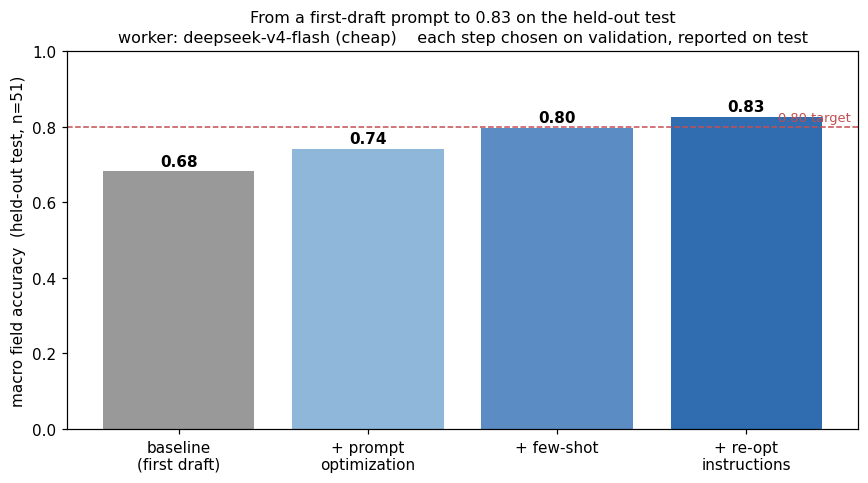

In [13]:
climb={"baseline\n(first draft)":score("baseline")["MACRO"],
       "+ prompt\noptimization":score("auto_iter")["MACRO"],
       "+ few-shot":score("fs9io_flash")["MACRO"],
       "+ re-opt\ninstructions":score("showcase")["MACRO"]}
fig,ax=plt.subplots(figsize=(8,4.5))
b=ax.bar(range(len(climb)),list(climb.values()),color=["#999999","#8FB7D9","#5B8CC4","#2F6DB0"])
ax.set_xticks(range(len(climb))); ax.set_xticklabels(list(climb.keys()))
ax.set_ylabel("macro field accuracy  (held-out test, n=51)"); ax.set_ylim(0,1)
ax.set_title("From a first-draft prompt to 0.83 on the held-out test\nworker: deepseek-v4-flash (cheap)    each step chosen on validation, reported on test",
             fontsize=10.5, linespacing=1.4)
for i,v in enumerate(climb.values()): ax.text(i,v+0.015,f"{v:.2f}",ha="center",fontweight="bold")
ax.axhline(0.80,ls="--",lw=1,color="#C44E52"); ax.text(len(climb)-0.45,0.808,"0.80 target",color="#C44E52",fontsize=8.5,ha="right",va="bottom")
fig.tight_layout(); fig.savefig("figures/m2_climb.png",dpi=150); plt.show()

In [14]:
# where the gains came from, per field
pd.DataFrame({"baseline":score("baseline"),"final (showcase)":score("showcase")}).round(3)

,baseline,final (showcase)
sensor_type,0.824,0.902
detect_target,0.843,0.941
lower_detection_limit,0.549,0.686
upper_detection_limit,0.608,0.725
probe_material,0.882,0.745
test_operating_temperature (celcius),0.333,0.902
pH_value,0.706,0.922
test_medium,0.706,0.784
MACRO,0.681,0.826


The big gains are on the learnable fields: temperature (a "room temperature means 25 C" convention), pH, detection limits, and the chemical fields once examples pin the granularity. What does not move is `probe_material` (about 0.75): the remaining misses are genuine, where the model picks the wrong component in a composite or misses the enzyme in a biosensor. That is the worker's real ceiling on this field, not a scoring artifact.

**A stronger worker did not help.** Swapping the worker to `deepseek-v4-pro` did not beat the cheap `flash` worker here (about 0.69 on the optimized prompt), so the cheap model plus a good prompt is the right choice. Measure before paying for a bigger model.

## 6. Scale, then audit

Run the final prompt over the whole corpus and produce the deliverable: a clean CSV plus a one-screen quality report.

In [15]:
final_prompt=open("reference/showcase_prompt.md").read()
allrecs={s: extract_paper(s, final_prompt, "showcase") for s in STEMS}   # cached
rows=[{"doi":s, **{f:r.get(f,"") for f in CORE}} for s,recs in allrecs.items() for r in (recs or [{}])]
data=pd.DataFrame(rows); data.to_csv("FET_sensor_extracted_dataset.csv",index=False)
print("wrote FET_sensor_extracted_dataset.csv with",len(data),"rows")
schema_ok=sum(1 for s in STEMS if (lambda r: (Extraction(records=r) or True))(allrecs[s]))/len(STEMS)
miss=data[CORE].apply(lambda c:(c.astype(str).str.strip()=="").mean()).round(3)
conc_ok=data["lower_detection_limit"].apply(lambda v: parse_conc(v) is not None or str(v).strip()=="").mean()
print(f"schema-valid: {schema_ok:.0%}   lower-limit parses to a unit: {conc_ok:.0%}")
print("missing-field rate:"); print(miss.to_string())
data.head(4)

wrote FET_sensor_extracted_dataset.csv with 150 rows
schema-valid: 100%   lower-limit parses to a unit: 90%
missing-field rate:
sensor_type                             0.013
detect_target                           0.013
lower_detection_limit                   0.040
upper_detection_limit                   0.167
probe_material                          0.013
test_operating_temperature (celcius)    0.013
pH_value                                0.013
test_medium                             0.013


,doi,sensor_type,detect_target,lower_detection_limit,upper_detection_limit,probe_material,test_operating_temperature (celcius),pH_value,test_medium
0,10.1002_adfm.200901830,liquid,H+,1e-10 M,1e-2 M,Polyisobutylmethacrylate,25 °C,2-10,water
1,10.1002_adfm.201001560,gas,nitrogen dioxide,10 ppb,3 ppm,zinc oxide,40 °C,-1,nitrogen
2,10.1002_adfm.201101324,gas,ammonia,4 ppm,60 ppm,"PIF-TBT/8-3-NTCDI (N,N′-Bis(3-(perfluoroctyl)p...",25 °C,-1,air
3,10.1002_adfm.201202473,gas,diethyl chlorophosphate,10 ppb,100 ppm,Benzothiadiazole-fused-tetrathiafulvalene (1),25 °C,-1,air


## 7. Make it yours

The pipeline transfers to any "documents to dataset" task:
- Put your texts in `data/papers/`, set your OpenRouter key, and flip `USE_CACHE=False`.
- Change the Pydantic `Record` to your fields; the field names and descriptions are your extraction spec.
- Hand-label 100 or more examples and split train / val / test, then adapt the three `field_match` rules to your field types.
- Climb: optimize the prompt against validation, add few-shot examples, re-optimize, and report once on test.

A few things to keep in mind: the evaluation is what lets you compare options; few-shot examples were the biggest single improvement here; a stronger worker model was not worth it; and some fields have a ceiling set by the ground truth, not the prompt.

## Source and citation
Data and task adapted from the T3 / text-to-data project:

> R. Ding et al., the T3 text-to-data extraction framework for FET biosensor literature. Cite the corresponding paper when using this material.

Worker and optimizer: `deepseek-v4-flash` and `deepseek-v4-pro` via OpenRouter.